# LPP - Parcellation Loss Analysis

How much voxel-level detail does parcellation throw away? We compare one subject's
**original voxel BOLD** against its **parcellated reconstruction** (each voxel repainted
with its parcel's mean), using four metrics:
1. **Explained variance** - how much voxel variance the parcels keep
2. **Within-parcel homogeneity** - how well each voxel matches its parcel mean
3. **SSIM** - structural similarity of the images
4. **PSNR** - peak signal-to-noise ratio

## Step 1 - Extract ONE subject's raw data (run in PowerShell)

This needs the original voxel BOLD, so download one run and **don't clean it up** until
the analysis below has finished.

```powershell
cd C:\TRIBE_Preprocessing\data\lpp
datalad get derivatives/sub-EN057/func/sub-EN057_task-lppEN_run-15_space-MNIColin27_desc-preproc_bold.nii.gz
```

## Step 2 - Setup

In [1]:
import os, sys
import numpy as np, nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image
from nilearn.maskers import NiftiLabelsMasker
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

PROJECT   = r"C:\TRIBE_Preprocessing"
ATLAS_DIR = os.path.join(PROJECT, "atlases")
sys.path.append(PROJECT)
import helpers.helpers_lpp as H

# the one run you extracted in Step 1:
BOLD_FILE = os.path.join(PROJECT, "data", "lpp", "derivatives", "sub-EN057", "func",
                         "sub-EN057_task-lppEN_run-15_space-MNIColin27_desc-preproc_bold.nii.gz")
print("Analysing:", os.path.basename(BOLD_FILE))

Analysing: sub-EN057_task-lppEN_run-15_space-MNIColin27_desc-preproc_bold.nii.gz


## Step 3 - Parcellate and reconstruct, then measure the loss

We build one combined atlas (cortex 1-1000, subcortex 1001-1032), average each parcel,
then paint those averages back onto the voxels - that 'reconstruction' is what the
parcellation preserves. The gap between it and the original is the lost detail.

In [2]:
bold = nib.load(BOLD_FILE)
cortex_atlas = H.get_cortical_atlas()
subc_atlas   = H.get_subcortical_atlas(ATLAS_DIR)

# Combine the two atlases on the BOLD grid.
sch = np.asarray(image.resample_to_img(cortex_atlas, bold, interpolation="nearest",
                 force_resample=True, copy_header=True).dataobj).astype(int)
tia = np.asarray(image.resample_to_img(subc_atlas, bold, interpolation="nearest",
                 force_resample=True, copy_header=True).dataobj).astype(int)
combined = sch.copy(); combined[tia > 0] = tia[tia > 0] + 1000
combined_img = nib.Nifti1Image(combined.astype(np.int32), bold.affine)

# Parcellate (average per region), then reconstruct (repaint voxels with parcel means).
masker  = NiftiLabelsMasker(combined_img, verbose=0)
parcels = masker.fit_transform(bold)            # (T, ~1032) the parcellated signal
recon   = masker.inverse_transform(parcels)     # voxels repainted with parcel means
print("parcellated signal:", parcels.shape)

# ---- the four metrics ----
orig = bold.get_fdata(dtype="float32")
rec  = recon.get_fdata(dtype="float32")
mask = combined > 0
o = orig[mask]; r = rec[mask]                    # (n_voxels, T) inside the parcels

ev = 1 - ((o - r).var() / o.var())              # 1. explained variance
oz = o - o.mean(1, keepdims=True); rz = r - r.mean(1, keepdims=True)
hom = ((oz*rz).sum(1) / (np.sqrt((oz**2).sum(1)*(rz**2).sum(1)) + 1e-9)).mean()  # 2. homogeneity
om = orig * mask[..., None]
ss, ps = [], []
for t in np.linspace(0, orig.shape[3]-1, 5, dtype=int):   # 3 & 4: a few frames
    a = om[..., t]; b = rec[..., t]; dr = float(a.max() - a.min())
    ss.append(ssim(a, b, data_range=dr)); ps.append(psnr(a, b, data_range=dr))

print(f"1. Explained variance retained : {ev*100:5.1f}%    (higher = less detail lost)")
print(f"2. Within-parcel homogeneity   : {hom:5.3f}      (1 = voxels match their parcel)")
print(f"3. SSIM (mean of 5 frames)     : {np.mean(ss):5.3f}      (1 = identical images)")
print(f"4. PSNR (mean of 5 frames)     : {np.mean(ps):5.1f} dB   (higher = closer)")

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\aryan\nilearn_data\schaefer_2018
parcellated signal: (282, 1032)
1. Explained variance retained :  44.6%    (higher = less detail lost)
2. Within-parcel homogeneity   : 0.580      (1 = voxels match their parcel)
3. SSIM (mean of 5 frames)     : 0.893      (1 = identical images)
4. PSNR (mean of 5 frames)     :  23.5 dB   (higher = closer)


### Visual: original vs parcellated vs the lost detail

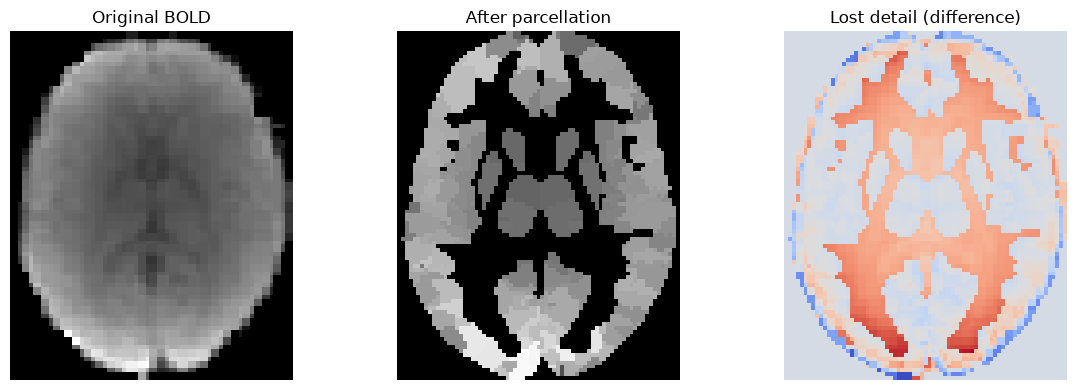

In [3]:
t = orig.shape[3] // 2; z = orig.shape[2] // 2     # middle frame, middle axial slice
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(orig[:, :, z, t].T, cmap="gray", origin="lower");  ax[0].set_title("Original BOLD")
ax[1].imshow(rec[:, :, z, t].T,  cmap="gray", origin="lower");  ax[1].set_title("After parcellation")
ax[2].imshow((orig[:, :, z, t] - rec[:, :, z, t]).T, cmap="coolwarm", origin="lower"); ax[2].set_title("Lost detail (difference)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Step 4 - Drop the raw data when done (run in PowerShell)

```powershell
cd C:\TRIBE_Preprocessing\data\lpp
datalad drop derivatives/sub-EN057/func
Remove-Item C:\TRIBE_Preprocessing\data\lpp\derivatives\sub-EN057\func\* -Force
```